# Stationarity

In [19]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="Set2")

In [20]:
def random_walk(obs=100, m=0, stdev=0.5, d=1):
    """
    :param: obs: number of observations
    :param: m: mean
    :param: stdev: standard deviation
    :param: d: number of dimensions
    """
    return np.cumsum(np.random.normal(m, stdev, (obs, d)))

def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def linear_trend(obs=100, d=1, y_start=0, y_stop=10):
    return np.linspace(start=y_start, stop=y_stop, num=obs).reshape(-1, 1).flatten()

def seasonality(obs=100, d=1, period=7, y_max=2):
    """
    :param: obs: number of observations
    :param: d: number of dimensions
    :param: period: period of the seasonal component
    :param: y_max: maximum value of the seasonal component
    """
    t = np.arange(obs)
    return y_max * np.sin(2 * np.pi * t / period).reshape(-1, d).flatten()

def structural_break(t, break_point=50, size=2):
    """:param: t: time points
    :param: break_point: index where the structural break occurs
    """
    t[break_point:] += size 
    return t

def segmented_trend(obs=100, y_start=0, y_stop=10, d=1, 
                    segment_start=0.5, segment_end=0.7, segment_y_start=1, segment_y_stop=5):
    segment_start = int(segment_start*obs)
    segment_end = int(segment_end*obs)
    t1 = linear_trend(segment_start, d, y_start=y_start, y_stop=segment_y_start)
    t2 = linear_trend(segment_end - segment_start, d, y_start=segment_y_start, y_stop=segment_y_stop)
    t3 = linear_trend(obs - segment_end, d, y_start=segment_y_stop, y_stop=y_stop)
    t = np.concatenate([t1, t2, t3])
    return t

def anomalies(t, anomaly_point=70, size=2):
    t[anomaly_point] += size  
    return t

# Random walk

<Axes: >

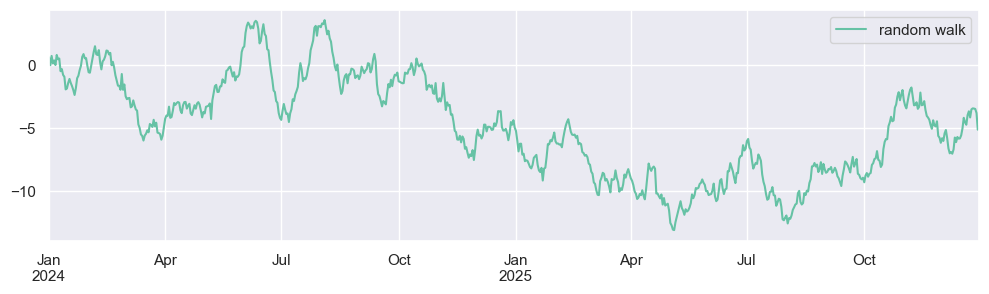

In [21]:
nobs = 365 * 2

rw = random_walk(obs=nobs, m=0, stdev=0.5, d=1)

dts = pd.date_range(start="2024-01-01", periods=nobs)
df = pd.DataFrame(rw, index=dts)
df.columns = ["random walk"]

df.plot(figsize=(12, 3), use_index=True)

# Spurious correlation

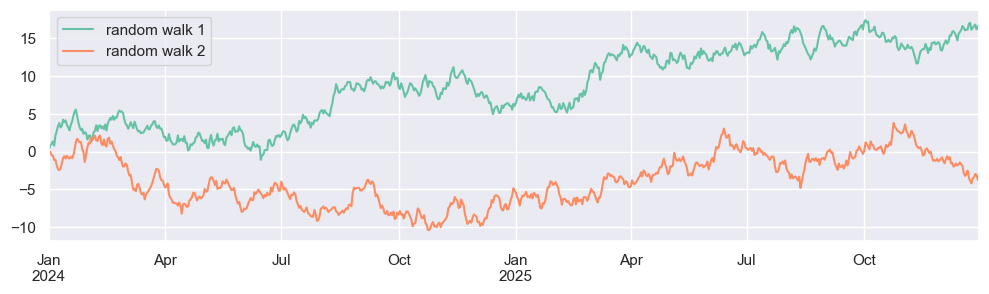

In [22]:
trials = []
for i in range(1000):
    rw1 = random_walk(obs=nobs, m=0, stdev=0.5, d=1)
    rw2 = random_walk(obs=nobs, m=0, stdev=0.5, d=1)
    corr = np.corrcoef(rw1.flatten(), rw2.flatten())[0, 1]
    trials.append(corr)

    if i == 0:
        df = pd.DataFrame({'random walk 1': rw1.flatten(), 'random walk 2': rw2.flatten()}, index=dts)
        df.plot(figsize=(12, 3), use_index=True)

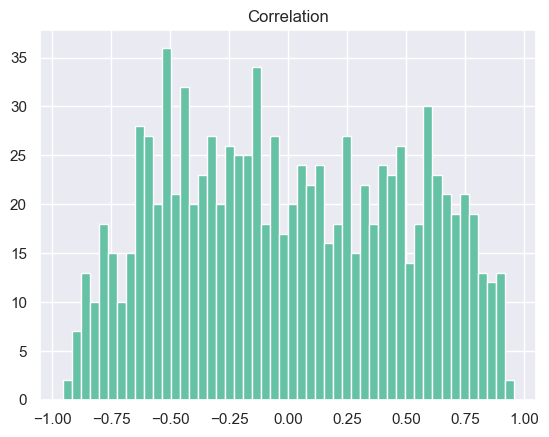

In [23]:
df = pd.DataFrame(trials, columns=["Correlation"])
hist = df.hist(bins=50)

# Spurious regression

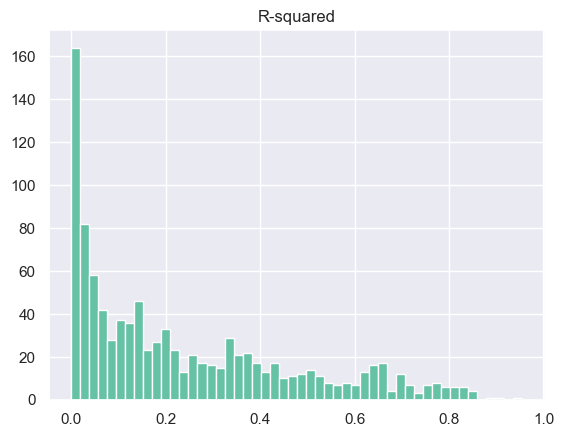

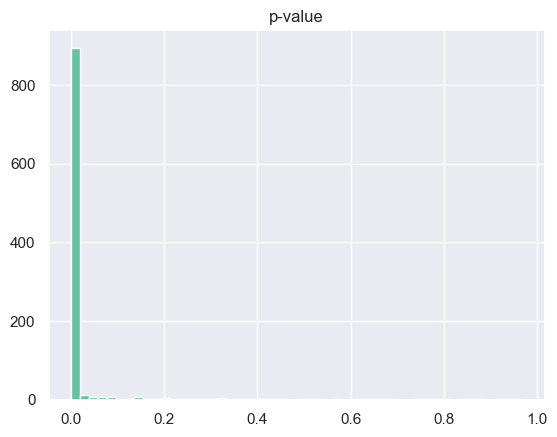

In [24]:
import statsmodels.api as sm

rsq_scores = []
p_vals = []
for i in range(1000):
    rw1 = random_walk(obs=nobs, m=0, stdev=0.5, d=1)
    rw2 = random_walk(obs=nobs, m=0, stdev=0.5, d=1)
    
    # Add intercept
    X = sm.add_constant(rw2.flatten())

    # Fit model
    model = sm.OLS(rw1.flatten(), X).fit()

    # Extract results
    r_squared = model.rsquared
    p_value = model.pvalues[1]

    rsq_scores.append(r_squared)
    p_vals.append(p_value)

df_rsq = pd.DataFrame(rsq_scores, columns=["R-squared"])
hist = df_rsq.hist(bins=50)
df_p = pd.DataFrame(p_vals, columns=["p-value"])
hist = df_p.hist(bins=50)

# ACF and PACF of Random Walk

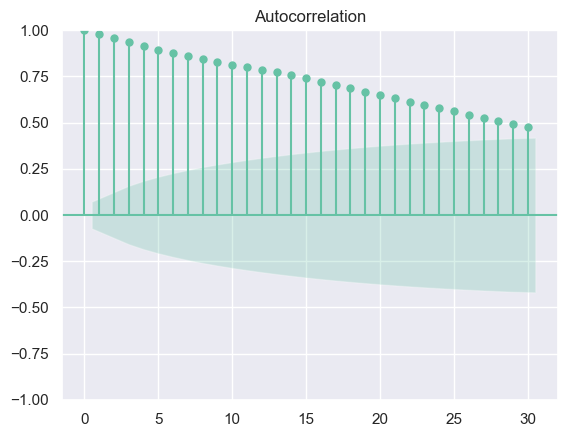

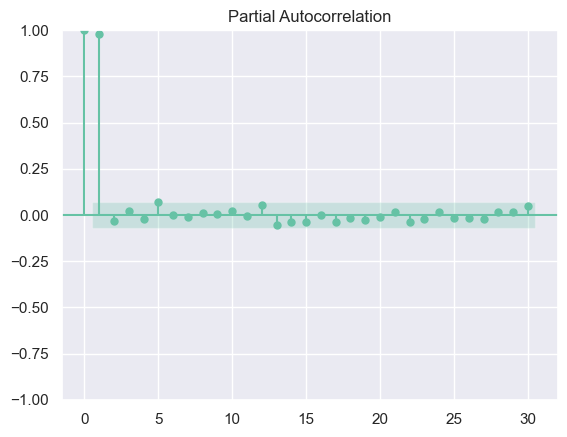

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

rw = random_walk(nobs, m=0, stdev=0.5, d=1)
_ = plot_acf(rw, lags=30)
_ = plot_pacf(rw, lags=30)

# Augmented Dickey-Fuller test

In [26]:
from statsmodels.tsa.stattools import adfuller

rw = random_walk(nobs, m=0, stdev=0.5, d=1)
wn = white_noise(nobs)
rn = red_noise(nobs, corr=0.7)

# random walk
adf_stat, pval, lags, obs, crit_vals, icbest = \
    adfuller(rw, regression="n")
print(f"ADF statistic: {adf_stat}")
print(f"p-value: {pval}")

ADF statistic: 1.471220512645313
p-value: 0.9648469797934078


In [27]:
# white noise
adf_stat, pval, lags, obs, crit_vals, icbest = \
    adfuller(wn, regression="n")
print(f"ADF statistic: {adf_stat}")
print(f"p-value: {pval}")

ADF statistic: -26.7515827512053
p-value: 0.0


In [28]:
# red noise
adf_stat, pval, lags, obs, crit_vals, icbest = \
    adfuller(rn, regression="n")
print(f"ADF statistic: {adf_stat}")
print(f"p-value: {pval}")

ADF statistic: -12.00883583615457
p-value: 6.883334217449834e-22


# KPSS test

In [29]:
from statsmodels.tsa.stattools import kpss

# random walk
kpss_stat, pval, lags, crit_vals = kpss(rw)

print(f"KPSS statistic: {kpss_stat}")
print(f"p-value: {pval}")

KPSS statistic: 1.9215231442799758
p-value: 0.01


C:\Users\pekarv\AppData\Local\Temp\ipykernel_31416\3438588568.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, pval, lags, crit_vals = kpss(rw)


In [30]:
# red noise
kpss_stat, pval, lags, crit_vals = kpss(rn)

print(f"KPSS statistic: {kpss_stat}")
print(f"p-value: {pval}")

KPSS statistic: 0.05006870593868393
p-value: 0.1


C:\Users\pekarv\AppData\Local\Temp\ipykernel_31416\2919874896.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, pval, lags, crit_vals = kpss(rn)
